In [1]:
%pip install minigrid gymnasium --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 69.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 160.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [minigrid]3/5 [gymnasium]e]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import json
import random
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
from PIL import Image

import gymnasium as gym
from minigrid.envs.empty import EmptyEnv


# ----------------------------
# Config
# ----------------------------
@dataclass
class Config:
    out_dir: str = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/data/emptyenv_sft_dataset"
    target_examples: int = 10000  # стартовый объём для SFT по шагам (не по эпизодам)
    sizes: Tuple[int, int] = (6, 7)
    seed: int = 42
    max_episodes: int = 100000  # safety
    save_jsonl_name: str = "dataset.jsonl"
    image_subdir: str = "images"
    # Если хочешь картинку "от первого лица", оставь "rgb_array".
    # Можно заменить на вид сверху, но это уже другая постановка.
    render_mode: str = "rgb_array"


# ----------------------------
# Expert planner for EmptyEnv
# ----------------------------
# MiniGrid directions are typically:
# 0: right (east), 1: down (south), 2: left (west), 3: up (north)
DIR_TO_VEC = {
    0: (1, 0),   # east
    1: (0, 1),   # south
    2: (-1, 0),  # west
    3: (0, -1),  # north
}

ACTION_TEXT = {
    0: "left",
    1: "right",
    2: "forward",
}

def turn_left(d: int) -> int:
    return (d - 1) % 4

def turn_right(d: int) -> int:
    return (d + 1) % 4

def shortest_path_next_action(agent_pos: Tuple[int, int], agent_dir: int, goal_pos: Tuple[int, int]) -> int:
    """
    Возвращает одно действие из {left, right, forward} как int:
    0=left, 1=right, 2=forward.

    Логика:
    - выбираем следующую клетку на кратчайшем (манхэттенском) пути к цели
      (сначала двигаем x, затем y).
    - если агент смотрит не туда, делаем один поворот (left/right), который уменьшает угол.
    - если смотрит туда, делаем forward.
    """
    ax, ay = agent_pos
    gx, gy = goal_pos

    # Выбираем желаемую следующую клетку (кратчайший путь в пустой решётке).
    # Можно поменять порядок (y потом x) или рандомизировать между осями — это даст разнообразие.
    if ax != gx:
        step_x = ax + (1 if gx > ax else -1)
        step_y = ay
    elif ay != gy:
        step_x = ax
        step_y = ay + (1 if gy > ay else -1)
    else:
        # Уже в цели — действие не нужно, но пусть будет forward (не должно вызываться)
        return 2

    dx = step_x - ax
    dy = step_y - ay

    # Требуемое направление, чтобы пойти в выбранную соседнюю клетку
    if (dx, dy) == (1, 0):
        req_dir = 0
    elif (dx, dy) == (0, 1):
        req_dir = 1
    elif (dx, dy) == (-1, 0):
        req_dir = 2
    elif (dx, dy) == (0, -1):
        req_dir = 3
    else:
        raise RuntimeError(f"Invalid step vector: {(dx, dy)}")

    if agent_dir == req_dir:
        return 2  # forward

    # Выбираем поворот, который быстрее приведёт к req_dir.
    # Считаем расстояние по модулю 4.
    # Например, из 0 в 2: можно left,left или right,right — выберем left по умолчанию.
    left_dist = (agent_dir - req_dir) % 4
    right_dist = (req_dir - agent_dir) % 4

    if left_dist <= right_dist:
        return 0  # left
    else:
        return 1  # right


# ----------------------------
# Dataset generation
# ----------------------------
def make_env(size: int, render_mode: str, seed: int) -> gym.Env:
    # Важно: agent_start_pos=None => агент будет размещён случайно (place_agent)
    # EmptyEnv также фиксирует цель, поэтому "случайность" в эпизодах идёт от старта/ориентации.
    env = EmptyEnv(size=size, agent_start_pos=None, render_mode=render_mode)
    env.reset(seed=seed)
    return env

def save_rgb_image(rgb: np.ndarray, path: str) -> None:
    # rgb обычно uint8 HxWx3
    im = Image.fromarray(rgb)
    im.save(path, format="PNG")

def main():
    cfg = Config()

    random.seed(cfg.seed)
    np.random.seed(cfg.seed)

    out_dir = cfg.out_dir
    img_dir = os.path.join(out_dir, cfg.image_subdir)
    os.makedirs(img_dir, exist_ok=True)

    jsonl_path = os.path.join(out_dir, cfg.save_jsonl_name)

    examples_written = 0
    episodes_done = 0

    with open(jsonl_path, "w", encoding="utf-8") as f:
        while examples_written < cfg.target_examples and episodes_done < cfg.max_episodes:
            size = random.choice(list(cfg.sizes))
            env_seed = cfg.seed + episodes_done * 1000 + size
            env = make_env(size=size, render_mode=cfg.render_mode, seed=env_seed)

            # Reset для нового эпизода
            obs, info = env.reset(seed=env_seed)

            # Случайная ориентация (стартовая позиция уже случайная)
            env.agent_dir = int(np.random.randint(0, 4))

            # goal обычно в (size-2, size-2) для EmptyEnv, но возьмём напрямую из grid.
            # В большинстве версий goal_pos доступен через env или можно найти в grid.
            # Тут аккуратно ищем объект Goal на grid.
            goal_pos = None
            for y in range(env.height):
                for x in range(env.width):
                    cell = env.grid.get(x, y)
                    if cell is not None and cell.type == "goal":
                        goal_pos = (x, y)
                        break
                if goal_pos is not None:
                    break
            if goal_pos is None:
                env.close()
                raise RuntimeError("Could not locate goal position in grid")

            terminated = False
            truncated = False

            step_idx = 0
            while not (terminated or truncated):
                # Рендерим "текущее состояние" (до действия)
                rgb = env.render()

                # Эксперт выбирает действие
                agent_pos = tuple(env.agent_pos)
                agent_dir = int(env.agent_dir)
                a = shortest_path_next_action(agent_pos, agent_dir, goal_pos)

                # Сохраняем пример (картинка -> действие текстом)
                img_name = f"sz{size}_ep{episodes_done:06d}_t{step_idx:03d}.png"
                img_path = os.path.join(cfg.image_subdir, img_name)
                save_rgb_image(rgb, os.path.join(out_dir, img_path))

                record = {
                    "image": img_path,
                    "action": ACTION_TEXT[a],
                    "size": size,
                    "episode_id": episodes_done,
                    "t": step_idx,
                }
                f.write(json.dumps(record, ensure_ascii=False) + "\n")

                examples_written += 1
                step_idx += 1

                # Делаем шаг в среде
                obs, reward, terminated, truncated, info = env.step(a)

                if examples_written >= cfg.target_examples:
                    break

            env.close()
            episodes_done += 1

    print(f"Done. Wrote {examples_written} examples across {episodes_done} episodes.")
    print(f"Dataset: {jsonl_path}")
    print(f"Images:  {img_dir}")


if __name__ == "__main__":
    main()

KeyboardInterrupt: 

right
images/sz7_ep000002_t003.png


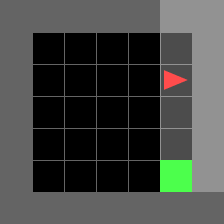

forward
images/sz7_ep000002_t004.png


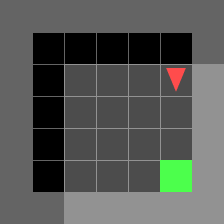

In [2]:
import json
from PIL import Image

idx = 13

for i in range(idx, idx+2):

    path = '/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/data/emptyenv_sft_dataset/'
    dataset_path = path + "dataset.jsonl"

    with open(dataset_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    sample = json.loads(lines[i])  # 10-й индекс

    print(sample["action"])
    print(sample["image"])

    img = Image.open(path + sample["image"])
    img.show() 